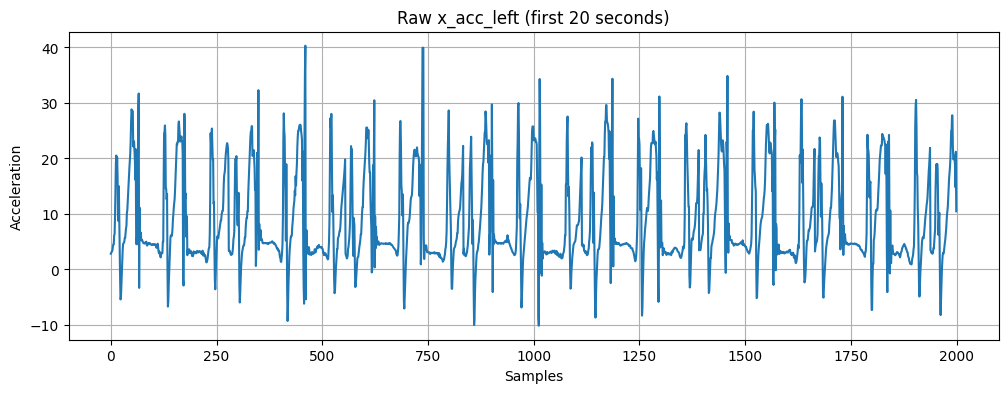

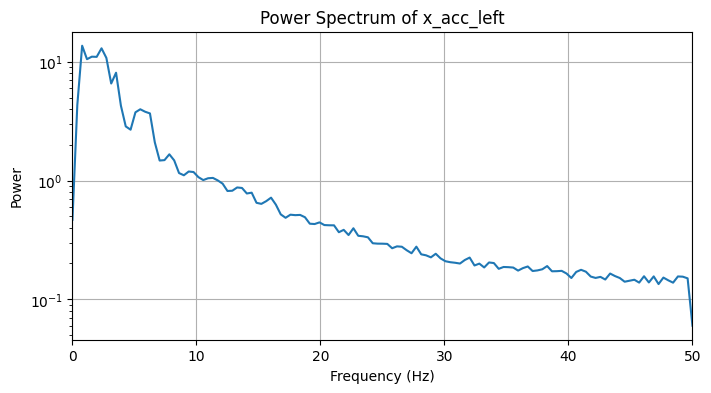

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# Load one subject
df = pd.read_csv("/kaggle/input/datasets/manelouchar/processed/S1.csv")

signal = df["x_acc_left"].values
fs = 100  # Hz

# ----------------------------
# Time-domain plot
# ----------------------------
plt.figure(figsize=(12,4))
plt.plot(signal[:2000])
plt.title("Raw x_acc_left (first 20 seconds)")
plt.xlabel("Samples")
plt.ylabel("Acceleration")
plt.grid()
plt.show()

# ----------------------------
# Frequency-domain plot
# ----------------------------
f, Pxx = welch(signal, fs=fs)

plt.figure(figsize=(8,4))
plt.semilogy(f, Pxx)
plt.xlim(0, 50)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.title("Power Spectrum of x_acc_left")
plt.grid()
plt.show()


In [2]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from scipy.signal import butter, filtfilt


class IMUPreprocessor:
    """
    IMU preprocessing:
    - Optional low-pass filtering (Butterworth)
    - Z-score normalization per subject (fit on TRAIN only)
    """

    def __init__(
        self,
        method: str = "zscore",
        use_lowpass: bool = False,
        cutoff_hz: float = 25.0,
        sampling_rate: int = 100,
        filter_order: int = 4
    ):
        self.method = method
        self.use_lowpass = use_lowpass
        self.cutoff_hz = cutoff_hz
        self.sampling_rate = sampling_rate
        self.filter_order = filter_order

        self.scalers = {}  # one scaler per subject

    # ---------------------------------------------------
    # Low-pass filter
    # ---------------------------------------------------
    def _apply_lowpass(self, X: np.ndarray) -> np.ndarray:
        if not self.use_lowpass:
            return X

        nyquist = self.sampling_rate / 2.0
        normal_cutoff = self.cutoff_hz / nyquist
        b, a = butter(self.filter_order, normal_cutoff, btype="low")

        X_filt = np.zeros_like(X)
        for i in range(X.shape[1]):
            X_filt[:, i] = filtfilt(b, a, X[:, i])

        return X_filt

    # ---------------------------------------------------
    # Fit scaler on TRAIN data only
    # ---------------------------------------------------
    def fit(self, X: np.ndarray, subject_id: str):
        """
        Fit normalization parameters for one subject (TRAIN only)
        """
        X = self._apply_lowpass(X)

        if self.method == "zscore":
            scaler = StandardScaler()
            scaler.fit(X)
            self.scalers[subject_id] = scaler
        else:
            raise ValueError(f"Unknown normalization method: {self.method}")

    # ---------------------------------------------------
    # Transform using fitted scaler
    # ---------------------------------------------------
    def transform(self, X: np.ndarray, subject_id: str) -> np.ndarray:
        """
        Apply filtering + normalization
        """
        if subject_id not in self.scalers:
            raise ValueError(f"Scaler not fitted for subject {subject_id}")

        X = self._apply_lowpass(X)
        return self.scalers[subject_id].transform(X)

    # ---------------------------------------------------
    # Fit + transform shortcut
    # ---------------------------------------------------
    def fit_transform(self, X: np.ndarray, subject_id: str) -> np.ndarray:
        self.fit(X, subject_id)
        return self.transform(X, subject_id)


In [3]:
import torch
import torch.nn as nn

class LSTMClassifier(nn.Module):
    """LSTM simple pour classification de gait modes"""
    
    def __init__(self, input_size: int, hidden_size: int = 256, 
                 num_layers: int = 2, num_classes: int = 5, 
                 dropout: float = 0.2, bidirectional: bool = False):
        """
        Args:
            input_size: nombre de features (27 dans votre cas)
            hidden_size: taille de la couche cachée LSTM
            num_layers: nombre de couches LSTM
            num_classes: nombre de classes (5)
            dropout: taux de dropout
            bidirectional: LSTM bidirectionnel ou non
        """
        super(LSTMClassifier, self).__init__()
        
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.bidirectional = bidirectional
        self.num_directions = 2 if bidirectional else 1
        
        # LSTM
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=bidirectional,
            batch_first=True
        )
        
        # Dropout
        self.dropout = nn.Dropout(dropout)
        
        # Couche de classification
        self.fc = nn.Linear(hidden_size * self.num_directions, num_classes)
    
    def forward(self, x):
        """Frame-wise classification (sortie à chaque timestep)"""
        lstm_out, _ = self.lstm(x)  # (batch, seq_len, hidden_size)
        lstm_out = self.dropout(lstm_out)
        
        # Appliquer FC à CHAQUE timestep
        batch_size, seq_len, hidden_dim = lstm_out.shape
        lstm_out_flat = lstm_out.reshape(-1, hidden_dim)
        logits_flat = self.fc(lstm_out_flat)
        
        return logits_flat.reshape(batch_size, seq_len, -1)  # (batch, seq_len, 5)
    
    def forward_sequence(self, x):
        """
        Forward avec output à chaque timestep (pour sequence labeling)
        
        Returns:
            logits: (batch, seq_len, num_classes)
        """
        lstm_out, _ = self.lstm(x)
        lstm_out = self.dropout(lstm_out)
        
        # Apply FC à chaque timestep
        # Reshape: (batch * seq_len, hidden_size * num_directions)
        batch_size, seq_len, hidden_dim = lstm_out.shape
        lstm_out_flat = lstm_out.reshape(-1, hidden_dim)
        
        # FC: (batch * seq_len, num_classes)
        logits_flat = self.fc(lstm_out_flat)
        
        # Reshape back: (batch, seq_len, num_classes)
        logits = logits_flat.reshape(batch_size, seq_len, -1)
        
        return logits

In [4]:
import numpy as np
from typing import Tuple, List

class WindowGenerator:
    """Génère des fenêtres glissantes pour l'entraînement LSTM"""
    
    def __init__(self, window_size: float = 2.5, overlap: float = 0.5, 
                 sampling_rate: int = 100):
        """
        Args:
            window_size: taille de la fenêtre en secondes
            overlap: pourcentage de chevauchement (0.0-1.0)
            sampling_rate: taux d'échantillonnage (Hz)
        """
        self.window_size_samples = int(window_size * sampling_rate)
        self.step_size_samples = int(self.window_size_samples * (1 - overlap))
        self.sampling_rate = sampling_rate
        
        print(f"Window config: {self.window_size_samples} samples, "
              f"step: {self.step_size_samples} samples")
    
    def create_windows(self, imu_data: np.ndarray, labels: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        """
        Crée des fenêtres glissantes
        
        Args:
            imu_data: (N, n_features)
            labels: (N,)
            
        Returns:
            X_windows: (n_windows, window_size, n_features)
            y_windows: (n_windows,) - label majoritaire dans chaque fenêtre
        """
        n_samples = len(imu_data)
        n_features = imu_data.shape[1]
        
        windows = []
        window_labels = []
        
        for start in range(0, n_samples - self.window_size_samples + 1, self.step_size_samples):
            end = start + self.window_size_samples
            
            # Extraire fenêtre
            window = imu_data[start:end]
            window_label_seq = labels[start:end]
            
            # Label = mode majoritaire dans la fenêtre
            # (stratégie simple, peut être améliorée)
            unique, counts = np.unique(window_label_seq, return_counts=True)
            majority_label = unique[np.argmax(counts)]
            
            windows.append(window)
            window_labels.append(majority_label)
        
        X_windows = np.array(windows)
        y_windows = np.array(window_labels)
        
        return X_windows, y_windows
    
    def create_windows_sequence_labeling(self, imu_data: np.ndarray, 
                                         labels: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        """
        Crée des fenêtres avec labels séquentiels (pour LSTM many-to-many)
        
        Returns:
            X_windows: (n_windows, window_size, n_features)
            y_windows: (n_windows, window_size) - label à chaque timestep
        """
        n_samples = len(imu_data)
        
        windows = []
        window_labels = []
        
        for start in range(0, n_samples - self.window_size_samples + 1, self.step_size_samples):
            end = start + self.window_size_samples
            
            window = imu_data[start:end]
            window_label_seq = labels[start:end]
            
            windows.append(window)
            window_labels.append(window_label_seq)
        
        return np.array(windows), np.array(window_labels)

In [5]:
import torch
import torch.nn as nn

class CNNLSTMClassifier(nn.Module):
    """
    CNN-LSTM Hybrid Architecture pour classification de modes de locomotion
    - CNN 1D: extraction de features locales temporelles
    - LSTM: capture des dépendances temporelles longues
    """
    
    def __init__(
        self, 
        input_size: int,
        num_classes: int = 5,
        # CNN params
        cnn_channels: list = [64, 128, 128],
        kernel_sizes: list = [5, 5, 3],
        # LSTM params
        hidden_size: int = 256,
        num_layers: int = 2,
        dropout: float = 0.2,
        bidirectional: bool = True
    ):
        """
        Args:
            input_size: nombre de features IMU (27)
            num_classes: nombre de classes (5)
            cnn_channels: canaux pour chaque couche CNN
            kernel_sizes: tailles de kernel pour chaque couche CNN
            hidden_size: taille LSTM
            num_layers: nombre de couches LSTM
            dropout: taux de dropout
            bidirectional: LSTM bidirectionnel
        """
        super(CNNLSTMClassifier, self).__init__()
        
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.bidirectional = bidirectional
        self.num_directions = 2 if bidirectional else 1
        
        # ========================================
        # CNN 1D Feature Extractor
        # ========================================
        cnn_layers = []
        in_channels = input_size
        
        for out_channels, kernel_size in zip(cnn_channels, kernel_sizes):
            cnn_layers.extend([
                nn.Conv1d(
                    in_channels=in_channels,
                    out_channels=out_channels,
                    kernel_size=kernel_size,
                    padding=kernel_size // 2  # same padding
                ),
                nn.BatchNorm1d(out_channels),
                nn.ReLU(),
                nn.Dropout(dropout * 0.5)  # dropout plus léger dans CNN
            ])
            in_channels = out_channels
        
        self.cnn = nn.Sequential(*cnn_layers)
        self.cnn_out_channels = cnn_channels[-1]
        
        # ========================================
        # LSTM Temporal Context
        # ========================================
        self.lstm = nn.LSTM(
            input_size=self.cnn_out_channels,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=bidirectional,
            batch_first=True
        )
        
        self.dropout = nn.Dropout(dropout)
        
        # ========================================
        # Classifier Head
        # ========================================
        self.fc = nn.Linear(hidden_size * self.num_directions, num_classes)
    
    def forward(self, x):
        """
        Forward pass avec sortie frame-wise
        
        Args:
            x: (batch, seq_len, input_size)
        
        Returns:
            logits: (batch, seq_len, num_classes)
        """
        batch_size, seq_len, input_size = x.shape
        
        # CNN attend (batch, channels, seq_len)
        x = x.transpose(1, 2)  # (batch, input_size, seq_len)
        
        # CNN feature extraction
        cnn_out = self.cnn(x)  # (batch, cnn_channels[-1], seq_len)
        
        # Retour à (batch, seq_len, channels) pour LSTM
        cnn_out = cnn_out.transpose(1, 2)
        
        # LSTM temporal modeling
        lstm_out, _ = self.lstm(cnn_out)  # (batch, seq_len, hidden_size * num_directions)
        lstm_out = self.dropout(lstm_out)
        
        # Classification frame-wise
        # Reshape pour appliquer FC à chaque timestep
        lstm_out_flat = lstm_out.reshape(-1, self.hidden_size * self.num_directions)
        logits_flat = self.fc(lstm_out_flat)
        
        # Reshape back
        logits = logits_flat.reshape(batch_size, seq_len, -1)
        
        return logits


class CNNLSTMClassifierDeep(nn.Module):
    """
    Version plus profonde avec Max Pooling pour réduire la dimension temporelle
    Utile pour des séquences très longues
    """
    
    def __init__(
        self,
        input_size: int,
        num_classes: int = 5,
        # CNN params
        cnn_channels: list = [64, 128, 256],
        kernel_sizes: list = [7, 5, 3],
        pool_sizes: list = [2, 2, 1],  # pooling après chaque conv
        # LSTM params
        hidden_size: int = 256,
        num_layers: int = 2,
        dropout: float = 0.2,
        bidirectional: bool = True
    ):
        super(CNNLSTMClassifierDeep, self).__init__()
        
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.bidirectional = bidirectional
        self.num_directions = 2 if bidirectional else 1
        self.pool_sizes = pool_sizes
        
        # CNN blocks with pooling
        cnn_layers = []
        in_channels = input_size
        
        for out_channels, kernel_size, pool_size in zip(cnn_channels, kernel_sizes, pool_sizes):
            cnn_layers.extend([
                nn.Conv1d(in_channels, out_channels, kernel_size, padding=kernel_size // 2),
                nn.BatchNorm1d(out_channels),
                nn.ReLU(),
                nn.MaxPool1d(pool_size) if pool_size > 1 else nn.Identity(),
                nn.Dropout(dropout * 0.5)
            ])
            in_channels = out_channels
        
        self.cnn = nn.Sequential(*cnn_layers)
        self.cnn_out_channels = cnn_channels[-1]
        
        # LSTM
        self.lstm = nn.LSTM(
            input_size=self.cnn_out_channels,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=bidirectional,
            batch_first=True
        )
        
        self.dropout = nn.Dropout(dropout)
        
        # Classifier
        self.fc = nn.Linear(hidden_size * self.num_directions, num_classes)
        
        # Upsampling pour revenir à la résolution originale
        total_pool = 1
        for p in pool_sizes:
            total_pool *= p
        self.upsample_factor = total_pool
    
    def forward(self, x):
        """
        Forward avec upsampling pour garder seq_len original
        """
        batch_size, seq_len, input_size = x.shape
        
        # CNN
        x = x.transpose(1, 2)
        cnn_out = self.cnn(x)
        cnn_out = cnn_out.transpose(1, 2)
        
        # LSTM
        lstm_out, _ = self.lstm(cnn_out)
        lstm_out = self.dropout(lstm_out)
        
        # Upsampling si nécessaire (interpolation linéaire)
        if self.upsample_factor > 1:
            lstm_out = lstm_out.transpose(1, 2)  # (batch, hidden, reduced_seq)
            lstm_out = nn.functional.interpolate(
                lstm_out, 
                size=seq_len, 
                mode='linear', 
                align_corners=False
            )
            lstm_out = lstm_out.transpose(1, 2)  # (batch, seq_len, hidden)
        
        # Classification
        lstm_out_flat = lstm_out.reshape(-1, self.hidden_size * self.num_directions)
        logits_flat = self.fc(lstm_out_flat)
        logits = logits_flat.reshape(batch_size, seq_len, -1)
        
        return logits


# ========================================
# Model Factory
# ========================================
def create_cnn_lstm_model(model_type: str = "standard", **kwargs):
    """
    Factory pour créer différentes variantes CNN-LSTM
    
    Args:
        model_type: "standard", "deep", ou "light"
        **kwargs: paramètres du modèle
    
    Returns:
        model: CNN-LSTM model
    """
    if model_type == "standard":
        return CNNLSTMClassifier(**kwargs)
    
    elif model_type == "deep":
        return CNNLSTMClassifierDeep(**kwargs)
    
    elif model_type == "light":
        # Version légère pour expérimentation rapide
        kwargs.update({
            'cnn_channels': [32, 64],
            'kernel_sizes': [5, 3],
            'hidden_size': 64,
            'num_layers': 1
        })
        return CNNLSTMClassifier(**kwargs)
    
    else:
        raise ValueError(f"Unknown model_type: {model_type}")


# ========================================
# Test du modèle
# ========================================
if __name__ == "__main__":
    # Test dimensions
    batch_size = 8
    seq_len = 150  # 1.5s @ 100Hz
    input_size = 27
    num_classes = 5
    
    # Dummy input
    x = torch.randn(batch_size, seq_len, input_size)
    
    print("="*60)
    print("Testing CNN-LSTM Models")
    print("="*60)
    
    # Standard model
    model_std = create_cnn_lstm_model(
        model_type="standard",
        input_size=input_size,
        num_classes=num_classes,
        cnn_channels=[64, 128, 128],
        kernel_sizes=[5, 5, 3],
        hidden_size=256,
        num_layers=2,
        dropout=0.2,
        bidirectional=True
    )
    
    print(f"\n1. Standard CNN-LSTM")
    print(f"   Parameters: {sum(p.numel() for p in model_std.parameters()):,}")
    
    logits_std = model_std(x)
    print(f"   Input:  {x.shape}")
    print(f"   Output: {logits_std.shape}")
    assert logits_std.shape == (batch_size, seq_len, num_classes), "Wrong output shape!"
    print("   ✓ Shape OK")
    
    # Deep model
    model_deep = create_cnn_lstm_model(
        model_type="deep",
        input_size=input_size,
        num_classes=num_classes,
        cnn_channels=[64, 128, 256],
        kernel_sizes=[7, 5, 3],
        pool_sizes=[2, 2, 1],
        hidden_size=256,
        num_layers=2,
        dropout=0.2,
        bidirectional=True
    )
    
    print(f"\n2. Deep CNN-LSTM (with pooling)")
    print(f"   Parameters: {sum(p.numel() for p in model_deep.parameters()):,}")
    
    logits_deep = model_deep(x)
    print(f"   Input:  {x.shape}")
    print(f"   Output: {logits_deep.shape}")
    assert logits_deep.shape == (batch_size, seq_len, num_classes), "Wrong output shape!"
    print("   ✓ Shape OK")
    
    # Light model
    model_light = create_cnn_lstm_model(
        model_type="light",
        input_size=input_size,
        num_classes=num_classes
    )
    
    print(f"\n3. Light CNN-LSTM")
    print(f"   Parameters: {sum(p.numel() for p in model_light.parameters()):,}")
    
    logits_light = model_light(x)
    print(f"   Input:  {x.shape}")
    print(f"   Output: {logits_light.shape}")
    assert logits_light.shape == (batch_size, seq_len, num_classes), "Wrong output shape!"
    print("   ✓ Shape OK")
    
    print(f"\n{'='*60}")
    print("All tests passed! ✓")
    print("="*60)

Testing CNN-LSTM Models

1. Standard CNN-LSTM
   Parameters: 2,469,765
   Input:  torch.Size([8, 150, 27])
   Output: torch.Size([8, 150, 5])
   ✓ Shape OK

2. Deep CNN-LSTM (with pooling)
   Parameters: 2,784,901
   Input:  torch.Size([8, 150, 27])
   Output: torch.Size([8, 150, 5])
   ✓ Shape OK

3. Light CNN-LSTM
   Parameters: 77,957
   Input:  torch.Size([8, 150, 27])
   Output: torch.Size([8, 150, 5])
   ✓ Shape OK

All tests passed! ✓


In [ ]:
# %%
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import yaml
import json
import time
from pathlib import Path
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (accuracy_score, f1_score, 
                             classification_report, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# ── All classes defined above (IMUPreprocessor, WindowGenerator,
#    LSTMClassifier, CNNLSTMClassifier, CNNLSTMClassifierDeep,
#    create_cnn_lstm_model) are already in this notebook ──


class LOSOTrainer:
    """
    Generic LOSO Trainer for LSTM and CNN-LSTM variants.
    Interface: (batch, seq_len, features) → (batch, seq_len, classes)
    """

    def __init__(
        self,
        model_type: str = "lstm",
        cnn_variant: str = "standard",
        config_path: str = '/kaggle/input/datasets/manelouchar/config/config.yaml'
    ):
        with open(config_path, 'r') as f:
            self.config = yaml.safe_load(f)

        self.model_type  = model_type
        self.cnn_variant = cnn_variant

        # ── Shared hyperparameters ──────────────────────────────
        self.window_size   = 2.5
        self.overlap       = 0.75
        self.num_classes   = len(self.config['data']['classes'])
        self.hidden_size   = 256
        self.num_layers    = 2
        self.dropout       = 0.3
        self.bidirectional = True
        self.learning_rate = 0.0005
        self.batch_size    = 32
        self.epochs        = 50
        self.patience      = 10

        # ── CNN-specific ────────────────────────────────────────
        self.cnn_channels = [64, 128, 128]
        self.kernel_sizes = [5, 5, 3]
        self.pool_sizes   = [2, 2, 1]          # deep variant only

        # ── Device & paths ──────────────────────────────────────
        self.device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        self.data_dir  = Path("/kaggle/input/datasets/manelouchar/processed")

        variant_tag = (f"{model_type}_{cnn_variant}" 
                       if model_type == "cnn_lstm" else model_type)
        base = Path('/kaggle/working')
        self.models_dir  = base / f'models_{variant_tag}'
        self.logs_dir    = base / f'logs_{variant_tag}'
        self.figures_dir = base / f'figures_{variant_tag}'
        self.reports_dir = base / f'reports_{variant_tag}'

        for d in [self.models_dir, self.logs_dir,
                  self.figures_dir, self.reports_dir]:
            d.mkdir(parents=True, exist_ok=True)

        self.log_file = self.logs_dir / f'{variant_tag}_log_{self.timestamp}.txt'

        self.log("=" * 70)
        self.log(f"Trainer: {variant_tag} | Device: {self.device}")
        self.log(f"Window: {self.window_size}s | Overlap: {self.overlap} | "
                 f"LR: {self.learning_rate} | Epochfs: {self.epochs}")
        self.log("=" * 70)

    # ── Logging ─────────────────────────────────────────────────────────
    def log(self, message: str):
        print(message)
        with open(self.log_file, 'a') as f:
            f.write(message + '\n')

    # ── Data loading ─────────────────────────────────────────────────────
    def load_subject_data(self, subject_id: str):
        file_path = self.data_dir / f"{subject_id}.csv"
        df = pd.read_csv(file_path)

        exclude_cols = ['time', 'label', 'label_idx']
        feature_cols = [c for c in df.columns if c not in exclude_cols]

        X = df[feature_cols].values
        y = df['label_idx'].values
        return X, y, feature_cols

    # ── Class weights ────────────────────────────────────────────────────
    def compute_class_weights(self, y_train_list):
        y_flat   = np.concatenate([y.flatten() for y in y_train_list])
        classes  = np.unique(y_flat)
        weights  = compute_class_weight('balanced', classes=classes, y=y_flat)
        return torch.FloatTensor(weights)

    # ── Model factory ────────────────────────────────────────────────────
    def _build_model(self, input_size: int) -> nn.Module:
        
        if self.model_type == "lstm":
            return LSTMClassifier(
                input_size=input_size,
                hidden_size=self.hidden_size,
                num_layers=self.num_layers,
                num_classes=self.num_classes,
                dropout=self.dropout,
                bidirectional=self.bidirectional
            )

        elif self.model_type == "cnn_lstm":
            base_kwargs = dict(
                input_size=input_size,
                num_classes=self.num_classes,
                hidden_size=self.hidden_size,
                num_layers=self.num_layers,
                dropout=self.dropout,
                bidirectional=self.bidirectional
            )

            if self.cnn_variant == "standard":
                return create_cnn_lstm_model(
                    model_type="standard",
                    cnn_channels=self.cnn_channels,
                    kernel_sizes=self.kernel_sizes,
                    **base_kwargs
                )

            elif self.cnn_variant == "deep":
                return create_cnn_lstm_model(
                    model_type="deep",
                    cnn_channels=[64, 128, 256],
                    kernel_sizes=[7, 5, 3],
                    pool_sizes=self.pool_sizes,
                    **base_kwargs
                )

            elif self.cnn_variant == "light":
                # Factory internally overrides hidden_size=64, num_layers=1
                return create_cnn_lstm_model(
                    model_type="light",
                    **base_kwargs
                )

            else:
                raise ValueError(f"Unknown cnn_variant: {self.cnn_variant}")

        else:
            raise ValueError(f"Unknown model_type: {self.model_type}")

    # ── Training ─────────────────────────────────────────────────────────
    def train_epoch(self, model, dataloader, criterion, optimizer) -> float:
        model.train()
        total_loss = 0.0

        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(self.device)
            y_batch = y_batch.to(self.device)

            optimizer.zero_grad()
            logits = model(X_batch)                          # (B, T, C)

            loss = criterion(
                logits.reshape(-1, self.num_classes),        # (B*T, C)
                y_batch.reshape(-1)                          # (B*T,)
            )

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()
            total_loss += loss.item()

        return total_loss / len(dataloader)

    # ── Evaluation ───────────────────────────────────────────────────────
    def evaluate(self, model, dataloader):
        model.eval()
        all_preds, all_labels = [], []

        with torch.no_grad():
            for X_batch, y_batch in dataloader:
                X_batch = X_batch.to(self.device)
                logits  = model(X_batch)
                preds   = torch.argmax(logits, dim=-1)

                all_preds.append(preds.cpu().numpy())
                all_labels.append(y_batch.numpy())

        all_preds  = np.concatenate([p.flatten() for p in all_preds])
        all_labels = np.concatenate([l.flatten() for l in all_labels])

        acc      = accuracy_score(all_labels, all_preds)
        f1_macro = f1_score(all_labels, all_preds, average='macro', zero_division=0)

        return acc, f1_macro, all_preds, all_labels

    # ── Plotting ─────────────────────────────────────────────────────────
    def plot_training_curves(self, history: dict, test_subject: str):
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        epochs = range(1, len(history['train_loss']) + 1)

        axes[0].plot(epochs, history['train_loss'], 'b-', linewidth=2)
        axes[0].set_title(f'Loss — {test_subject}')
        axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
        axes[0].grid(True, alpha=0.3)

        axes[1].plot(epochs, history['val_acc'], 'g-', label='Accuracy', linewidth=2)
        axes[1].plot(epochs, history['val_f1'],  'r-', label='F1 Macro', linewidth=2)
        axes[1].set_title(f'Validation — {test_subject}')
        axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Score')
        axes[1].legend(); axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig(self.figures_dir / f'curves_{test_subject}.png', dpi=150)
        plt.close()

    def plot_confusion_matrix(self, cm: np.ndarray, test_subject: str):
        fig, ax = plt.subplots(figsize=(8, 6))
        sns.heatmap(
            cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=self.config['data']['classes'],
            yticklabels=self.config['data']['classes']
        )
        ax.set_xlabel('Predicted'); ax.set_ylabel('True')
        ax.set_title(f'Confusion Matrix — {test_subject}')
        plt.tight_layout()
        plt.savefig(self.figures_dir / f'cm_{test_subject}.png', dpi=150)
        plt.close()

    def plot_summary_results(self, all_results: list):
        subjects   = [r['test_subject'] for r in all_results]
        accuracies = [r['accuracy']     for r in all_results]
        f1_scores  = [r['f1_macro']     for r in all_results]

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        mean_acc = np.mean(accuracies)
        mean_f1  = np.mean(f1_scores)

        for ax, values, mean, title, ylabel in [
            (axes[0], accuracies, mean_acc, 'Accuracy (LOSO)', 'Accuracy'),
            (axes[1], f1_scores,  mean_f1,  'F1 Macro (LOSO)', 'F1 Macro'),
        ]:
            colors = ['green' if v > mean else 'coral' for v in values]
            ax.bar(subjects, values, color=colors, alpha=0.7, edgecolor='black')
            ax.axhline(mean, color='red', linestyle='--', linewidth=2,
                       label=f'Mean: {mean:.4f}')
            ax.set_title(f'{self.model_type} {self.cnn_variant} — {title}')
            ax.set_xlabel('Test Subject'); ax.set_ylabel(ylabel)
            ax.legend(); ax.grid(axis='y', alpha=0.3)
            plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

        plt.tight_layout()
        plt.savefig(self.figures_dir / 'summary.png', dpi=300)
        plt.close()

    # ── Per-fold training ────────────────────────────────────────────────
    def train_fold(self, test_subject: str, all_subjects: list) -> dict:
        self.log(f"\n{'='*70}")
        self.log(f"FOLD: {test_subject} | {self.model_type} / {self.cnn_variant}")
        self.log(f"{'='*70}")

        train_subjects = [s for s in all_subjects if s != test_subject]
        val_subject    = train_subjects[-1]          # last subject as validation
        train_subjects = train_subjects[:-1]         # remaining 8 for training

        # Load
        train_data = {}
        for subj in train_subjects:
            X, y, _ = self.load_subject_data(subj)
            train_data[subj] = {'X': X, 'y': y}
        X_test_raw, y_test_raw, _ = self.load_subject_data(test_subject)

        # Preprocess — fit on train only
        preprocessor = IMUPreprocessor(method="zscore", use_lowpass=False)
        X_train_all  = np.vstack([train_data[s]['X'] for s in train_subjects])
        preprocessor.fit(X_train_all, subject_id='global_train')

        # Window
        windower = WindowGenerator(window_size=self.window_size, overlap=self.overlap)

        # ── load val subject raw data ──
        X_val_raw, y_val_raw, _ = self.load_subject_data(val_subject)
        
        # ── fit preprocessor on train subjects only (exclude val too) ──
        X_train_all  = np.vstack([train_data[s]['X'] for s in train_subjects])
        preprocessor.fit(X_train_all, subject_id='global_train')
        
        X_train_list, y_train_list = [], []
        for subj in train_subjects:
            X_norm       = preprocessor.transform(train_data[subj]['X'], 'global_train')
            X_win, y_win = windower.create_windows_sequence_labeling(
                X_norm, train_data[subj]['y']
            )
            X_train_list.append(X_win)
            y_train_list.append(y_win)
        
        X_train = np.concatenate(X_train_list)
        y_train = np.concatenate(y_train_list)
        
        # ── validation set (held-out train subject, never the test subject) ──
        X_val_norm     = preprocessor.transform(X_val_raw, 'global_train')
        X_val, y_val   = windower.create_windows_sequence_labeling(X_val_norm, y_val_raw)
        
        # ── true test set (only touched for final evaluation) ──
        X_test_norm    = preprocessor.transform(X_test_raw, 'global_train')
        X_test, y_test = windower.create_windows_sequence_labeling(X_test_norm, y_test_raw)

        self.log(f"Train subjects: {train_subjects} | Val: {val_subject} | Test: {test_subject}")
        self.log(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")

        # DataLoaders
        train_loader = DataLoader(
            TensorDataset(torch.FloatTensor(X_train), torch.LongTensor(y_train)),
            batch_size=self.batch_size, shuffle=True, drop_last=True
        )

        val_loader = DataLoader(
            TensorDataset(torch.FloatTensor(X_val), torch.LongTensor(y_val)),
            batch_size=self.batch_size, shuffle=False
        )

        test_loader = DataLoader(
            TensorDataset(torch.FloatTensor(X_test), torch.LongTensor(y_test)),
            batch_size=self.batch_size, shuffle=False
        )

        # Model
        input_size = X_train.shape[2]
        model      = self._build_model(input_size).to(self.device)
        n_params   = sum(p.numel() for p in model.parameters())
        self.log(f"Parameters: {n_params:,}")

        # Loss / optimizer / scheduler
        class_weights = self.compute_class_weights(y_train_list).to(self.device)
        criterion     = nn.CrossEntropyLoss(weight=class_weights)
        optimizer     = optim.Adam(model.parameters(), lr=self.learning_rate)
        scheduler     = optim.lr_scheduler.CosineAnnealingWarmRestarts(
            optimizer, T_0=10, T_mult=2
        )

        # Training loop
        best_val_f1     = 0.0
        patience_counter = 0
        history         = {'train_loss': [], 'val_acc': [], 'val_f1': []}
        model_path      = self.models_dir / f'{self.model_type}_{self.cnn_variant}_{test_subject}.pth'

        for epoch in range(self.epochs):
            train_loss         = self.train_epoch(model, train_loader, criterion, optimizer)
            val_acc, val_f1, _, _ = self.evaluate(model, val_loader)    

            history['train_loss'].append(train_loss)
            history['val_acc'].append(val_acc)
            history['val_f1'].append(val_f1)

            scheduler.step(epoch)

            self.log(f"Ep {epoch+1:3d}/{self.epochs} | "
                     f"Loss: {train_loss:.4f} | Acc: {val_acc:.4f} | F1: {val_f1:.4f}")

            if val_f1 > best_val_f1:
                best_val_f1      = val_f1
                patience_counter = 0
                torch.save({
                    'model_state_dict': model.state_dict(),
                    'val_f1':           val_f1,
                    'epoch':            epoch,
                    'n_params':         n_params
                }, model_path)
                self.log(f"  ✓ Best saved (F1: {val_f1:.4f})")
            else:
                patience_counter += 1
                if patience_counter >= self.patience:
                    self.log(f"  Early stopping at epoch {epoch+1}")
                    break

        # Final evaluation with best checkpoint
        checkpoint = torch.load(model_path, weights_only=False)
        model.load_state_dict(checkpoint['model_state_dict'])
        final_acc, final_f1, preds, labels = self.evaluate(model, test_loader)

        self.log(f"\nFinal — Acc: {final_acc:.4f} | F1: {final_f1:.4f}")

        self.plot_training_curves(history, test_subject)
        cm     = confusion_matrix(labels, preds)
        self.plot_confusion_matrix(cm, test_subject)

        report = classification_report(
            labels, preds,
            target_names=self.config['data']['classes'],
            output_dict=True
        )
        self.log(classification_report(
            labels, preds, target_names=self.config['data']['classes']
        ))

        return {
            'test_subject':      test_subject,
            'accuracy':          float(final_acc),
            'f1_macro':          float(final_f1),
            'per_class_f1':      {cls: report[cls]['f1-score']
                                  for cls in self.config['data']['classes']},
            'num_train_windows': int(len(X_train)),
            'num_test_windows':  int(len(X_test)),
            'n_params':          n_params,
            'confusion_matrix':  cm.tolist(),
            'training_history':  history
        }

    # ── LOSO loop ────────────────────────────────────────────────────────
    def run_loso(self) -> dict:
        all_files    = sorted(self.data_dir.glob('*.csv'))
        all_subjects = [f.stem for f in all_files]

        self.log(f"\nSubjects ({len(all_subjects)}): {all_subjects}")

        all_results = []
        for test_subject in all_subjects:
            result = self.train_fold(test_subject, all_subjects)
            all_results.append(result)

        accuracies = [r['accuracy'] for r in all_results]
        f1_scores  = [r['f1_macro'] for r in all_results]

        self.log(f"\n{'='*70}")
        self.log("LOSO COMPLETE")
        self.log(f"Accuracy : {np.mean(accuracies):.4f} ± {np.std(accuracies):.4f}")
        self.log(f"F1 Macro : {np.mean(f1_scores):.4f}  ± {np.std(f1_scores):.4f}")
        self.log(f"{'='*70}")

        self.plot_summary_results(all_results)

        # Save JSON
        final = {
            'timestamp':      self.timestamp,
            'model_type':     self.model_type,
            'cnn_variant':    self.cnn_variant,
            'mean_accuracy':  float(np.mean(accuracies)),
            'std_accuracy':   float(np.std(accuracies)),
            'mean_f1_macro':  float(np.mean(f1_scores)),
            'std_f1_macro':   float(np.std(f1_scores)),
            'fold_results':   all_results
        }

        out = self.models_dir / f'results_{self.timestamp}.json'
        with open(out, 'w') as f:
            json.dump(final, f, indent=2)
        self.log(f"✓ Results → {out}")

        return final


# %%
if __name__ == "__main__":

    experiments = [
        {"model_type": "lstm",     "cnn_variant": "standard", "label": "LSTM"},
        {"model_type": "cnn_lstm", "cnn_variant": "standard", "label": "CNN-LSTM Standard"},
        {"model_type": "cnn_lstm", "cnn_variant": "deep",     "label": "CNN-LSTM Deep"},
        {"model_type": "cnn_lstm", "cnn_variant": "light",    "label": "CNN-LSTM Light"},
    ]

    all_experiment_results = {}
    experiment_times       = {}

    print("\n" + "="*70)
    print(f"  Running {len(experiments)} experiments")
    print("="*70)

    for exp in experiments:
        label = exp["label"]
        print(f"\n{'─'*70}\n  Starting: {label}\n{'─'*70}\n")

        t_start = time.time()
        trainer = LOSOTrainer(
            model_type=exp["model_type"],
            cnn_variant=exp["cnn_variant"]
        )
        results = trainer.run_loso()
        elapsed = time.time() - t_start

        all_experiment_results[label] = results
        experiment_times[label]       = elapsed

        print(f"\n  ✓ {label} — {elapsed/60:.1f} min | "
              f"Acc: {results['mean_accuracy']:.4f} | "
              f"F1: {results['mean_f1_macro']:.4f}")

    # ── Comparison table ────────────────────────────────────────────────
    print("\n" + "="*70)
    print("  FINAL COMPARISON")
    print("="*70)
    print(f"\n{'Model':<22} {'Acc':>8} {'±':>6} {'F1':>8} {'±':>6} {'Time':>8}")
    print("─"*62)

    for label, res in all_experiment_results.items():
        print(
            f"{label:<22} "
            f"{res['mean_accuracy']:>8.4f} "
            f"{res['std_accuracy']:>6.4f} "
            f"{res['mean_f1_macro']:>8.4f} "
            f"{res['std_f1_macro']:>6.4f} "
            f"{experiment_times[label]/60:>7.1f}m"
        )

    print("─"*62)

    # ── Save comparison ─────────────────────────────────────────────────
    comparison = {
        label: {
            "mean_accuracy": res["mean_accuracy"],
            "std_accuracy":  res["std_accuracy"],
            "mean_f1_macro": res["mean_f1_macro"],
            "std_f1_macro":  res["std_f1_macro"],
            "time_minutes":  round(experiment_times[label] / 60, 2)
        }
        for label, res in all_experiment_results.items()
    }

    out = Path('/kaggle/working') / 'experiment_comparison.json'
    with open(out, 'w') as f:
        json.dump(comparison, f, indent=2)

    print(f"\n  ✓ Comparison saved → {out}")
    print("\n  🎉 All experiments complete!\n")


  Running 4 experiments

──────────────────────────────────────────────────────────────────────
  Starting: LSTM
──────────────────────────────────────────────────────────────────────

Trainer: lstm | Device: cuda
Window: 2.5s | Overlap: 0.75 | LR: 0.0005 | Epochfs: 50

Subjects (10): ['S1', 'S10', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9']

FOLD: S1 | lstm / standard
Window config: 250 samples, step: 62 samples
Train subjects: ['S10', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8'] | Val: S9 | Test: S1
Train: (3518, 250, 27) | Val: (427, 250, 27) | Test: (474, 250, 27)
Parameters: 2,163,205
Ep   1/50 | Loss: 0.6016 | Acc: 0.8215 | F1: 0.8258
  ✓ Best saved (F1: 0.8258)
Ep   2/50 | Loss: 0.2404 | Acc: 0.8094 | F1: 0.8305
  ✓ Best saved (F1: 0.8305)
Ep   3/50 | Loss: 0.1768 | Acc: 0.9021 | F1: 0.8952
  ✓ Best saved (F1: 0.8952)
Ep   4/50 | Loss: 0.1156 | Acc: 0.9286 | F1: 0.9230
  ✓ Best saved (F1: 0.9230)
Ep   5/50 | Loss: 0.0882 | Acc: 0.9131 | F1: 0.9093


In [ ]:
import shutil
import os

source_dir = "/kaggle/working"
zip_path = "/kaggle/working/results-256"

shutil.make_archive(
    base_name=zip_path,
    format="zip",
    root_dir=source_dir
)

print("Zip created at:", zip_path + ".zip")